# **1. Perkenalan Dataset**

Dataset yang digunakan pada eksperimen ini adalah **Telco Customer Churn**
(sumber: Kaggle / IBM Sample Data Sets). Dataset berisi 7.043 baris pelanggan
sebuah perusahaan telekomunikasi dengan 21 kolom yang mencakup informasi
demografis, layanan yang dilanggan, informasi akun, dan label apakah pelanggan
berhenti berlangganan (`Churn`).

**Tujuan:** membangun model klasifikasi biner untuk memprediksi apakah seorang
pelanggan akan *churn* (berhenti) atau tidak.

| Kelompok kolom | Contoh fitur |
|----------------|--------------|
| Demografi | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| Layanan | `PhoneService`, `InternetService`, `OnlineSecurity`, `StreamingTV` |
| Akun | `tenure`, `Contract`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges` |
| Target | `Churn` (Yes/No) |


# **2. Import Library**

Mengimpor pustaka yang dibutuhkan untuk analisis data (pandas, numpy),
visualisasi (matplotlib, seaborn), dan preprocessing (scikit-learn).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print("Library berhasil diimpor.")

Library berhasil diimpor.


# **3. Memuat Dataset**

Memuat dataset mentah dari berkas `telco_raw.csv` dan menampilkan beberapa baris
awal untuk memastikan data terbaca dengan benar.

In [2]:
RAW_PATH = "../telco_raw.csv"
df = pd.read_csv(RAW_PATH)
print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Informasi struktur kolom dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Statistik deskriptif untuk fitur numerik
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# **4. Exploratory Data Analysis (EDA)**

Tahap ini bertujuan memahami karakteristik data sebelum melakukan preprocessing.
Kita memeriksa distribusi target, nilai hilang, distribusi fitur numerik, serta
hubungan beberapa fitur kategorikal terhadap churn.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporsi churn:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


C:\Users\maste\AppData\Local\Temp\ipykernel_28084\2537353251.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette="Set2")


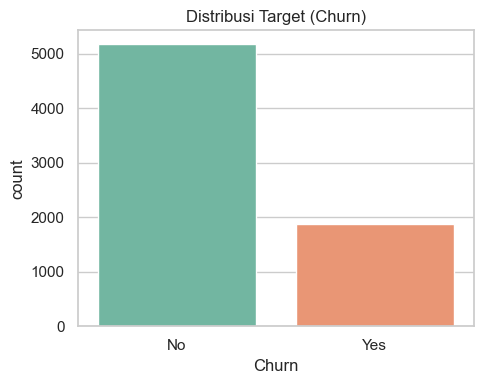

In [5]:
# 4.1 Distribusi target (Churn)
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print("\nProporsi churn:")
print(df["Churn"].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn", palette="Set2")
plt.title("Distribusi Target (Churn)")
plt.tight_layout()
plt.show()

In [6]:
# 4.2 Pemeriksaan nilai hilang & tipe data bermasalah
# TotalCharges seharusnya numerik, tetapi terbaca sebagai object.
print("Tipe TotalCharges:", df["TotalCharges"].dtype)

# Baris dengan TotalCharges berupa string kosong (pelanggan baru, tenure 0)
blank_total = df[df["TotalCharges"].str.strip() == ""]
print("Jumlah baris TotalCharges kosong:", len(blank_total))

print("\nMissing values per kolom:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "Tidak ada NaN eksplisit.")

print("\nJumlah duplikat:", df.duplicated().sum())

Tipe TotalCharges: object
Jumlah baris TotalCharges kosong: 11

Missing values per kolom:
Tidak ada NaN eksplisit.

Jumlah duplikat: 0


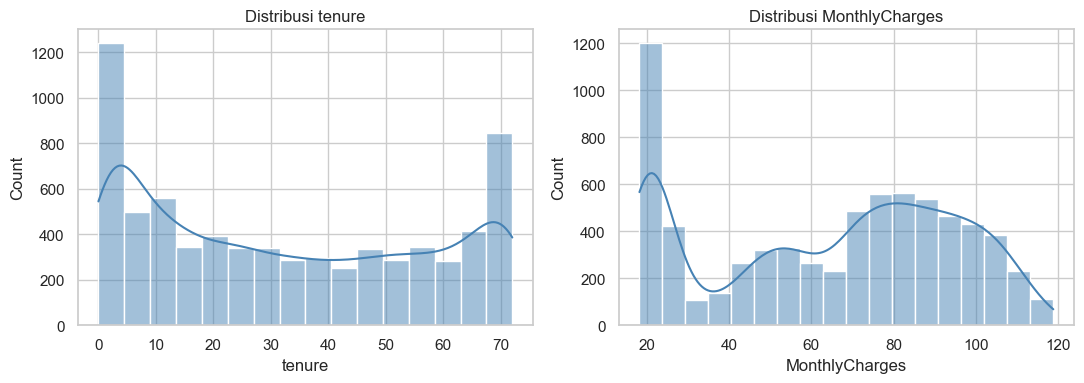

In [7]:
# 4.3 Distribusi fitur numerik
num_cols = ["tenure", "MonthlyCharges"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribusi {col}")
plt.tight_layout()
plt.show()

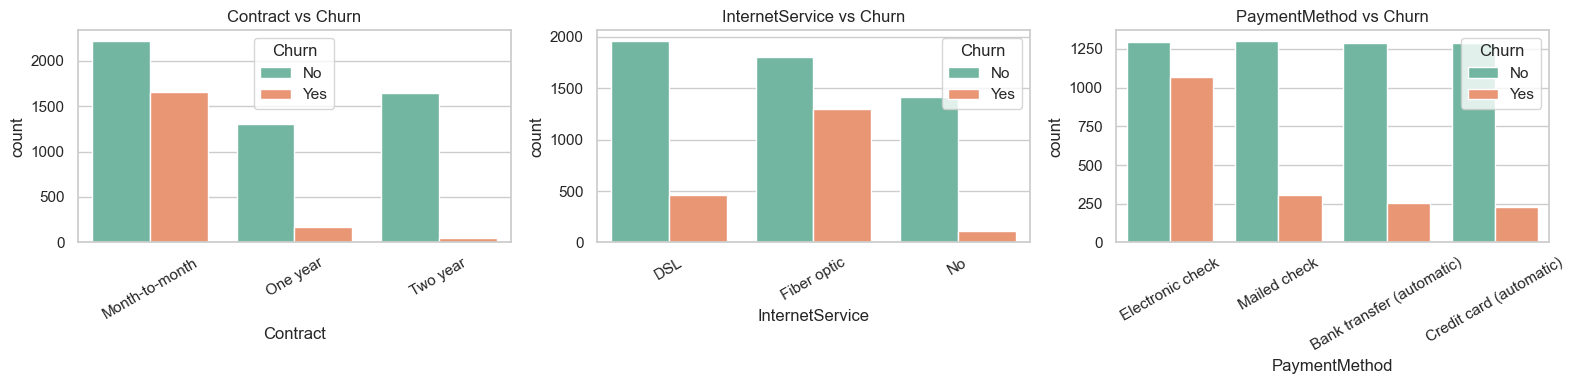

In [8]:
# 4.4 Hubungan fitur kategorikal terhadap churn
cat_cols = ["Contract", "InternetService", "PaymentMethod"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, hue="Churn", ax=ax, palette="Set2")
    ax.set_title(f"{col} vs Churn")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

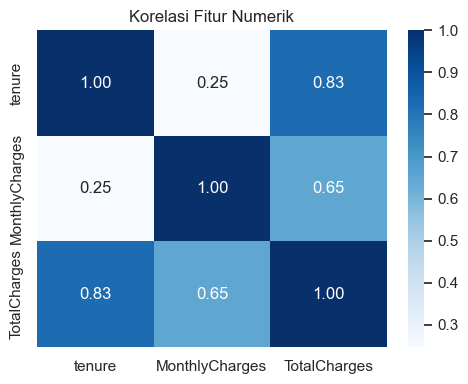

In [9]:
# 4.5 Korelasi fitur numerik (setelah TotalCharges dikonversi sementara)
tmp = df.copy()
tmp["TotalCharges"] = pd.to_numeric(tmp["TotalCharges"], errors="coerce")
corr = tmp[["tenure", "MonthlyCharges", "TotalCharges"]].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

**Insight EDA:**

- Dataset tidak seimbang: sekitar 26,5% pelanggan melakukan churn.
- `TotalCharges` terbaca sebagai *object* karena ada 11 baris berisi string
  kosong (pelanggan dengan `tenure` = 0). Ini perlu dikonversi ke numerik dan
  baris kosongnya ditangani.
- Pelanggan dengan kontrak *Month-to-month*, layanan *Fiber optic*, dan metode
  pembayaran *Electronic check* cenderung lebih banyak melakukan churn.
- `tenure` dan `TotalCharges` berkorelasi tinggi (pelanggan lama membayar lebih
  banyak secara akumulatif).

# **5. Data Preprocessing**

Langkah preprocessing berikut diterapkan dan kemudian dikonversi menjadi fungsi
otomatis pada `automate_Hilmi.py`:

1. Menghapus kolom identifier (`customerID`).
2. Mengonversi `TotalCharges` ke numerik dan menangani nilai kosong (NaN).
3. Menghapus baris duplikat.
4. Encoding target `Churn` (Yes/No -> 1/0).
5. One-hot encoding fitur kategorikal.
6. Train/test split (stratified) dan standardisasi fitur numerik.

In [10]:
# 5.1 Hapus identifier & perbaiki TotalCharges
data = df.copy()
data = data.drop(columns=["customerID"])
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# 5.2 Tangani nilai hilang & duplikat
print("Sebelum:", data.shape)
data = data.dropna()
data = data.drop_duplicates().reset_index(drop=True)
print("Sesudah :", data.shape)

Sebelum: (7043, 20)
Sesudah : (7010, 20)


In [11]:
# 5.3 Encoding target
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0}).astype(int)

# 5.4 One-hot encoding fitur kategorikal
categorical_cols = data.select_dtypes(include="object").columns.tolist()
print("Kolom kategorikal yang di-encode:", categorical_cols)

data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
bool_cols = data.select_dtypes(include="bool").columns
data[bool_cols] = data[bool_cols].astype(int)
print("Ukuran setelah encoding:", data.shape)
data.head()

Kolom kategorikal yang di-encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Ukuran setelah encoding: (7010, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


In [12]:
# 5.5 Train/test split + standardisasi fitur numerik
X = data.drop(columns=["Churn"])
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (5608, 30) | X_test: (1402, 30)


In [13]:
# 5.6 Simpan dataset hasil preprocessing (siap dilatih)
import os
import joblib

OUTPUT_DIR = "telco_preprocessing"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_out = X_train.copy()
train_out["Churn"] = y_train.values
test_out = X_test.copy()
test_out["Churn"] = y_test.values

train_out.to_csv(os.path.join(OUTPUT_DIR, "train.csv"), index=False)
test_out.to_csv(os.path.join(OUTPUT_DIR, "test.csv"), index=False)
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "scaler.pkl"))

print("Dataset hasil preprocessing tersimpan di:", os.path.abspath(OUTPUT_DIR))
print("Jumlah fitur akhir:", X_train.shape[1])

Dataset hasil preprocessing tersimpan di:

 D:\Research\Project Data\Hackathon\Membangun Sistem Machine Learning\Eksperimen_SML_Hilmi\preprocessing\telco_preprocessing
Jumlah fitur akhir: 30


**Kesimpulan**

Seluruh tahapan eksplorasi (data loading, EDA, dan preprocessing) telah
dilakukan secara manual pada notebook ini. Langkah-langkah preprocessing
tersebut selanjutnya dikonversi menjadi fungsi otomatis pada
`automate_Hilmi.py`, sehingga menghasilkan dataset siap latih
(`telco_preprocessing/train.csv` dan `telco_preprocessing/test.csv`) yang
digunakan pada kriteria berikutnya (pembangunan model dengan MLflow).

*Author: Hilmi — https://master-hilmi.vercel.app/*